# PM2.5 Forecasting

This notebook develops a machine-learning forecasting pipeline to predict the next day's average PM2.5 concentration for Delhi.

The forecasting dataset is derived from the integrated environmental dataset containing hourly weather and air-quality observations for 2025.

## Objectives

- Convert hourly environmental observations into daily observations
- Create historical lag features
- Create rolling statistical features
- Incorporate weather information
- Maintain chronological ordering
- Split the data using a time-based train/test split
- Establish a persistence baseline
- Train machine-learning regression models
- Evaluate models using MAE, RMSE and R²
- Select the best-performing forecasting model
- Visualize actual vs predicted PM2.5 values

## Target Variable

The target variable is:

`next_day_pm2_5`

representing the following day's average PM2.5 concentration in µg/m³.

> The forecasting model is intended for project-level prediction and demonstration. It is not an official air-quality forecasting service.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor
)

pd.set_option("display.max_columns", None)

In [5]:
data_path = Path(
    "../data/processed/environmental_dataset.csv"
)

df = pd.read_csv(data_path)

df["time"] = pd.to_datetime(df["time"])

df = (
    df
    .sort_values("time")
    .reset_index(drop=True)
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (8760, 21)


,time,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_gusts_10m,year,month,day,hour,day_of_year,season,rain_flag,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone
0,2025-01-01 00:00:00,8.3,100,7.4,0.0,99,2.8,4.7,2025,1,1,0,1,Winter,0,185.8,188.6,1645.0,56.7,49.7,31.0
1,2025-01-01 01:00:00,8.0,100,7.0,0.0,100,2.9,5.4,2025,1,1,1,1,Winter,0,174.6,177.4,1551.0,44.8,39.7,39.0
2,2025-01-01 02:00:00,7.8,100,6.5,0.0,100,4.7,10.1,2025,1,1,2,1,Winter,0,164.4,166.7,1478.0,34.6,31.5,46.0
3,2025-01-01 03:00:00,8.0,99,6.5,0.0,100,5.8,12.6,2025,1,1,3,1,Winter,0,156.5,158.8,1418.0,26.7,26.0,52.0
4,2025-01-01 04:00:00,7.7,98,6.1,0.0,100,6.3,13.0,2025,1,1,4,1,Winter,0,149.5,151.8,1379.0,20.6,22.3,57.0


In [6]:
daily_df = (
    df.set_index("time")
      .resample("D")
      .agg({
          "pm2_5": "mean",
          "pm10": "mean",
          "carbon_monoxide": "mean",
          "nitrogen_dioxide": "mean",
          "sulphur_dioxide": "mean",
          "ozone": "mean",
          "temperature_2m": "mean",
          "relative_humidity_2m": "mean",
          "apparent_temperature": "mean",
          "precipitation": "sum",
          "cloud_cover": "mean",
          "wind_speed_10m": "mean",
          "wind_gusts_10m": "mean"
      })
      .reset_index()
)

In [7]:
print("Daily dataset shape:", daily_df.shape)

daily_df.head()

Daily dataset shape: (365, 14)


,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_gusts_10m
0,2025-01-01,145.175000,147.837500,1414.083333,34.616667,31.283333,77.375000,11.162500,88.875000,10.108333,0.0,51.666667,5.850000,14.191667
1,2025-01-02,145.370833,149.341667,1576.791667,33.241667,38.100000,81.291667,12.383333,85.125000,11.354167,0.0,85.375000,6.662500,15.183333
2,2025-01-03,158.791667,168.179167,2099.125000,54.083333,48.366667,62.875000,12.845833,86.000000,12.345833,0.0,74.708333,4.241667,10.083333
3,2025-01-04,166.491667,176.479167,2588.583333,76.295833,63.462500,77.208333,13.495833,88.833333,13.391667,0.0,27.250000,4.200000,10.516667
4,2025-01-05,158.225000,163.804167,1660.958333,44.412500,48.441667,94.333333,12.458333,89.708333,11.737500,0.0,32.916667,6.362500,15.166667


In [8]:
print("Start date:", daily_df["time"].min())
print("End date:", daily_df["time"].max())

print("Number of days:", len(daily_df))
print(
    "Missing values:",
    daily_df.isnull().sum().sum()
)

Start date: 2025-01-01 00:00:00
End date: 2025-12-31 00:00:00
Number of days: 365
Missing values: 0


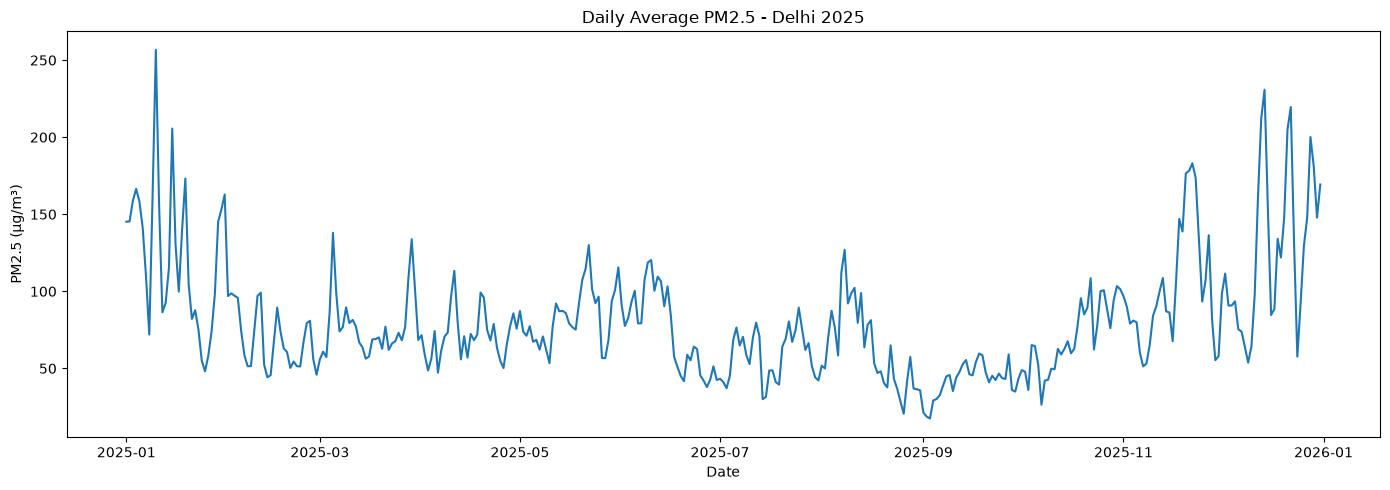

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(
    daily_df["time"],
    daily_df["pm2_5"]
)

plt.title("Daily Average PM2.5 - Delhi 2025")
plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")

plt.tight_layout()
plt.show()

In [10]:
# Current-day PM2.5
daily_df["pm25_current"] = daily_df["pm2_5"]

# Historical PM2.5 lags
daily_df["pm25_lag_1"] = (
    daily_df["pm2_5"].shift(1)
)

daily_df["pm25_lag_2"] = (
    daily_df["pm2_5"].shift(2)
)

daily_df["pm25_lag_3"] = (
    daily_df["pm2_5"].shift(3)
)

daily_df["pm25_lag_7"] = (
    daily_df["pm2_5"].shift(7)
)

daily_df["pm25_lag_14"] = (
    daily_df["pm2_5"].shift(14)
)

In [11]:
daily_df["month_sin"] = np.sin(
    2 * np.pi * daily_df["month"] / 12
)

daily_df["month_cos"] = np.cos(
    2 * np.pi * daily_df["month"] / 12
)

daily_df["day_of_year_sin"] = np.sin(
    2 * np.pi * daily_df["day_of_year"] / 365
)

daily_df["day_of_year_cos"] = np.cos(
    2 * np.pi * daily_df["day_of_year"] / 365
)

In [12]:
daily_df["pm25_lag_1"] = (
    daily_df["pm2_5"].shift(1)
)

daily_df["pm25_lag_2"] = (
    daily_df["pm2_5"].shift(2)
)

daily_df["pm25_lag_3"] = (
    daily_df["pm2_5"].shift(3)
)

daily_df["pm25_lag_7"] = (
    daily_df["pm2_5"].shift(7)
)

In [13]:
daily_df["pm25_rolling_3"] = (
    daily_df["pm2_5"]
    .shift(1)
    .rolling(3)
    .mean()
)

daily_df["pm25_rolling_7"] = (
    daily_df["pm2_5"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily_df["pm25_rolling_14"] = (
    daily_df["pm2_5"]
    .shift(1)
    .rolling(14)
    .mean()
)

In [14]:
daily_df["pm25_change_1d"] = (
    daily_df["pm25_lag_1"]
    - daily_df["pm25_lag_2"]
)

daily_df["pm25_change_3d"] = (
    daily_df["pm25_lag_1"]
    - daily_df["pm25_lag_3"]
)

daily_df["pm25_ratio_7d"] = (
    daily_df["pm25_lag_1"]
    / daily_df["pm25_rolling_7"]
)

In [15]:
daily_df["pm25_rolling_std_7"] = (
    daily_df["pm2_5"]
    .shift(1)
    .rolling(7)
    .std()
)

daily_df["pm25_rolling_max_7"] = (
    daily_df["pm2_5"]
    .shift(1)
    .rolling(7)
    .max()
)

daily_df["pm25_rolling_min_7"] = (
    daily_df["pm2_5"]
    .shift(1)
    .rolling(7)
    .min()
)

In [16]:
pollution_features = [
    "pm2_5",
    "pm10",
    "carbon_monoxide",
    "nitrogen_dioxide",
    "sulphur_dioxide",
    "ozone"
]

weather_features = [
    "temperature_2m",
    "relative_humidity_2m",
    "apparent_temperature",
    "precipitation",
    "cloud_cover",
    "wind_speed_10m",
    "wind_gusts_10m"
]

for feature in pollution_features + weather_features:
    daily_df[f"{feature}_lag_1"] = (
        daily_df[feature].shift(1)
    )

In [17]:
daily_df["next_day_pm2_5"] = (
    daily_df["pm2_5"].shift(-1)
)

In [18]:
forecast_df = (
    daily_df
    .dropna()
    .reset_index(drop=True)
)

print("Forecasting dataset shape:", forecast_df.shape)

Forecasting dataset shape: (350, 48)


In [19]:
forecast_df.head(10)

,time,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,temperature_2m,relative_humidity_2m,apparent_temperature,precipitation,cloud_cover,wind_speed_10m,wind_gusts_10m,month,day_of_year,day_of_week,month_sin,month_cos,day_of_year_sin,day_of_year_cos,pm25_lag_1,pm25_lag_2,pm25_lag_3,pm25_lag_7,pm25_rolling_3,pm25_rolling_7,pm25_rolling_14,pm25_change_1d,pm25_change_3d,pm25_ratio_7d,pm25_rolling_std_7,pm25_rolling_max_7,pm25_rolling_min_7,pm2_5_lag_1,pm10_lag_1,carbon_monoxide_lag_1,nitrogen_dioxide_lag_1,sulphur_dioxide_lag_1,ozone_lag_1,temperature_2m_lag_1,relative_humidity_2m_lag_1,apparent_temperature_lag_1,precipitation_lag_1,cloud_cover_lag_1,wind_speed_10m_lag_1,wind_gusts_10m_lag_1,next_day_pm2_5
0,2025-01-15,205.625000,208.487500,2345.958333,83.179167,66.683333,69.458333,13.062500,87.166667,12.808333,2.9,61.208333,3.379167,10.170833,1,15,2,0.5,0.866025,0.255353,0.966848,115.350000,92.587500,86.391667,71.920833,98.109722,134.212500,140.322321,22.762500,28.958333,0.859458,63.820312,256.733333,71.920833,115.350000,116.233333,1708.708333,47.804167,49.104167,82.666667,13.254167,82.875000,12.670833,0.0,0.041667,4.691667,11.895833,130.758333
1,2025-01-16,130.758333,132.800000,1154.791667,49.562500,44.729167,62.250000,13.912500,83.708333,13.570833,0.7,43.666667,4.258333,10.183333,1,16,3,0.5,0.866025,0.271958,0.962309,205.625000,115.350000,92.587500,161.037500,137.854167,153.313095,144.640179,90.275000,113.037500,1.341210,62.053549,256.733333,86.391667,205.625000,208.487500,2345.958333,83.179167,66.683333,69.458333,13.062500,87.166667,12.808333,2.9,61.208333,3.379167,10.170833,99.833333
2,2025-01-17,99.833333,101.016667,1054.916667,28.979167,36.133333,72.583333,13.200000,80.666667,12.158333,0.0,1.000000,6.833333,15.833333,1,17,4,0.5,0.866025,0.288482,0.957485,130.758333,205.625000,115.350000,256.733333,150.577778,148.987500,143.596429,-74.866667,15.408333,0.877646,62.479240,256.733333,86.391667,130.758333,132.800000,1154.791667,49.562500,44.729167,62.250000,13.912500,83.708333,13.570833,0.7,43.666667,4.258333,10.183333,139.700000
3,2025-01-18,139.700000,142.308333,2035.333333,54.279167,55.237500,58.708333,12.300000,86.416667,11.666667,0.0,52.083333,4.175000,11.525000,1,18,5,0.5,0.866025,0.304921,0.952378,99.833333,130.758333,205.625000,155.466667,145.405556,126.573214,139.385119,-30.925000,-105.791667,0.788740,42.253400,205.625000,86.391667,99.833333,101.016667,1054.916667,28.979167,36.133333,72.583333,13.200000,80.666667,12.158333,0.0,1.000000,6.833333,15.833333,173.145833
4,2025-01-19,173.145833,176.079167,2446.125000,71.783333,80.641667,68.083333,14.629167,85.833333,14.866667,0.0,63.083333,3.162500,9.120833,1,19,6,0.5,0.866025,0.321270,0.946988,139.700000,99.833333,130.758333,86.391667,123.430556,124.320833,137.471429,39.866667,8.941667,1.123705,40.853534,205.625000,86.391667,139.700000,142.308333,2035.333333,54.279167,55.237500,58.708333,12.300000,86.416667,11.666667,0.0,52.083333,4.175000,11.525000,104.754167
5,2025-01-20,104.754167,105.491667,1409.208333,31.387500,33.554167,77.375000,16.354167,83.166667,16.375000,0.0,10.208333,7.458333,16.866667,1,20,0,0.5,0.866025,0.337523,0.941317,173.145833,139.700000,99.833333,92.587500,137.559722,136.714286,138.537202,33.445833,73.312500,1.266479,40.587647,205.625000,92.587500,173.145833,176.079167,2446.125000,71.783333,80.641667,68.083333,14.629167,85.833333,14.866667,0.0,63.083333,3.162500,9.120833,82.075000
6,2025-01-21,82.075000,83.145833,1234.125000,26.108333,25.745833,86.208333,15.987500,77.958333,15.508333,0.0,0.166667,7.425000,16.641667,1,21,1,0.5,0.866025,0.353676,0.935368,104.754167,173.145833,139.700000,115.350000,139.200000,138.452381,135.933631,-68.391667,-34.945833,0.756608,38.594628,205.625000,99.833333,104.754167,105.491667,1409.208333,31.387500,33.554167,77.375000,16.354167,83.166667,16.375000,0.0,10.208333,7.458333,16.866667,87.745833
7,2025-01-22,87.745833,93.775000,1228.583333,41.900000,35.500000,65.833333,16.187500,75.250000,15.954167,0.0,6.33333

In [20]:
feature_columns = [
    # PM2.5 history
    "pm25_lag_1",
    "pm25_lag_2",
    "pm25_lag_3",
    "pm25_lag_7",

    # PM2.5 rolling statistics
    "pm25_rolling_3",
    "pm25_rolling_7",
    "pm25_rolling_14",
    "pm25_rolling_std_7",
    "pm25_rolling_max_7",
    "pm25_rolling_min_7",

    # PM2.5 trend
    "pm25_change_1d",
    "pm25_change_3d",
    "pm25_ratio_7d",

    # Yesterday's pollution
    "pm10_lag_1",
    "carbon_monoxide_lag_1",
    "nitrogen_dioxide_lag_1",
    "sulphur_dioxide_lag_1",
    "ozone_lag_1",

    # Yesterday's weather
    "temperature_2m_lag_1",
    "relative_humidity_2m_lag_1",
    "apparent_temperature_lag_1",
    "precipitation_lag_1",
    "cloud_cover_lag_1",
    "wind_speed_10m_lag_1",
    "wind_gusts_10m_lag_1",

    # Calendar
    "month_sin",
    "month_cos",
    "day_of_year_sin",
    "day_of_year_cos"
]

X = forecast_df[feature_columns]

y = forecast_df["next_day_pm2_5"]

In [21]:
split_index = int(len(forecast_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "\nTraining period:",
    forecast_df["time"].iloc[0],
    "to",
    forecast_df["time"].iloc[split_index - 1]
)

print(
    "Testing period:",
    forecast_df["time"].iloc[split_index],
    "to",
    forecast_df["time"].iloc[-1]
)

Training samples: 280
Testing samples: 70

Training period: 2025-01-15 00:00:00 to 2025-10-21 00:00:00
Testing period: 2025-10-22 00:00:00 to 2025-12-30 00:00:00


In [22]:
baseline_predictions = (
    forecast_df["pm25_lag_1"]
    .iloc[split_index:]
)

baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_predictions
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)

print("Baseline Performance")
print("--------------------")
print("MAE :", round(baseline_mae, 2))
print("RMSE:", round(baseline_rmse, 2))
print("R²  :", round(baseline_r2, 4))

Baseline Performance
--------------------
MAE : 37.26
RMSE: 49.41
R²  : -0.2102


In [23]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

In [24]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression")
print("-----------------")
print("MAE :", round(linear_mae, 2))
print("RMSE:", round(linear_rmse, 2))
print("R²  :", round(linear_r2, 4))

Linear Regression
-----------------
MAE : 34.59
RMSE: 47.7
R²  : -0.1277


In [25]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

In [26]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest")
print("-------------")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------
MAE : 35.45
RMSE: 47.79
R²  : -0.1323


In [27]:
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_predictions = gb_model.predict(
    X_test
)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_predictions
    )
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting")
print("-----------------")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R²  :", round(gb_r2, 4))

Gradient Boosting
-----------------
MAE : 35.66
RMSE: 47.81
R²  : -0.1329


In [28]:
extra_model = ExtraTreesRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

extra_model.fit(
    X_train,
    y_train
)

extra_predictions = extra_model.predict(
    X_test
)

extra_mae = mean_absolute_error(
    y_test,
    extra_predictions
)

extra_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        extra_predictions
    )
)

extra_r2 = r2_score(
    y_test,
    extra_predictions
)

print("Extra Trees")
print("-----------")
print("MAE :", round(extra_mae, 2))
print("RMSE:", round(extra_rmse, 2))
print("R²  :", round(extra_r2, 4))

Extra Trees
-----------
MAE : 33.86
RMSE: 44.28
R²  : 0.0279


In [29]:
results = pd.DataFrame({
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Extra Trees"
    ],
    "MAE": [
        baseline_mae,
        linear_mae,
        rf_mae,
        gb_mae,
        extra_mae
    ],
    "RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse,
        gb_rmse,
        extra_rmse
    ],
    "R2": [
        baseline_r2,
        linear_r2,
        rf_r2,
        gb_r2,
        extra_r2
    ]
})

results = (
    results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

results

,Model,MAE,RMSE,R2
0,Extra Trees,33.858946,44.283096,0.027893
1,Linear Regression,34.592504,47.695215,-0.127685
2,Random Forest,35.449692,47.793076,-0.132317
3,Gradient Boosting,35.656738,47.805670,-0.132914
4,Baseline,37.257024,49.408605,-0.210162


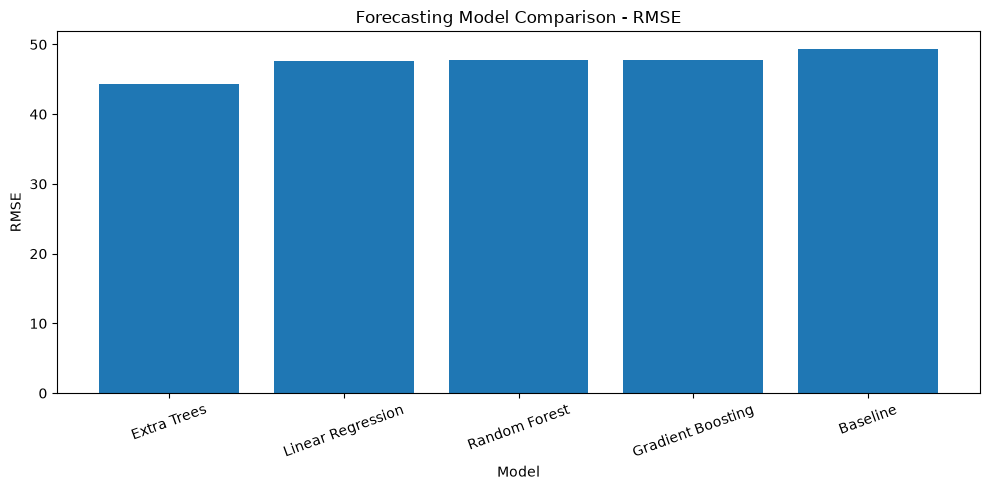

In [30]:
plt.figure(figsize=(10, 5))

plt.bar(
    results["Model"],
    results["RMSE"]
)

plt.title("Forecasting Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [37]:
best_predictions = {
    "Extra Trees": extra_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosting": gb_predictions,
    "Linear Regression": linear_predictions,
    "Baseline": baseline_predictions
}[best_model_name]

comparison_df = pd.DataFrame({
    "date": forecast_df["time"].iloc[split_index:].values,
    "actual_pm2_5": y_test.values,
    "predicted_pm2_5": best_predictions
})

comparison_df.head()

,date,actual_pm2_5,predicted_pm2_5
0,2025-10-22,62.229167,80.273275
1,2025-10-23,77.720833,90.022614
2,2025-10-24,100.062500,80.383470
3,2025-10-25,100.733333,82.831310
4,2025-10-26,88.579167,84.320858


In [32]:
comparison_df = pd.DataFrame({
    "date": forecast_df["time"].iloc[split_index:].values,
    "actual_pm2_5": y_test.values,
    "predicted_pm2_5": gb_predictions
})

comparison_df.head()

,date,actual_pm2_5,predicted_pm2_5
0,2025-10-22,62.229167,62.905322
1,2025-10-23,77.720833,84.486702
2,2025-10-24,100.062500,71.576086
3,2025-10-25,100.733333,81.834644
4,2025-10-26,88.579167,95.609173


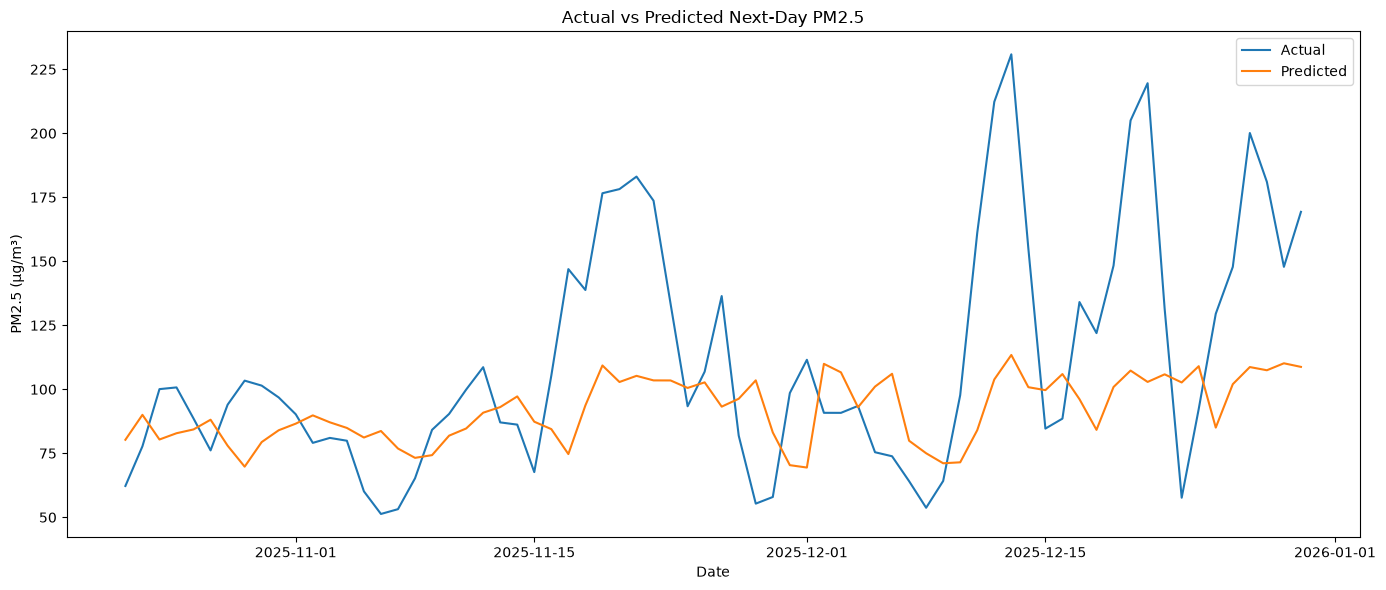

In [38]:
plt.figure(figsize=(14, 6))

plt.plot(
    comparison_df["date"],
    comparison_df["actual_pm2_5"],
    label="Actual"
)

plt.plot(
    comparison_df["date"],
    comparison_df["predicted_pm2_5"],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Next-Day PM2.5"
)

plt.xlabel("Date")
plt.ylabel("PM2.5 (µg/m³)")

plt.legend()

plt.tight_layout()
plt.show()

In [39]:
comparison_df["error"] = (
    comparison_df["actual_pm2_5"]
    - comparison_df["predicted_pm2_5"]
)

comparison_df["absolute_error"] = (
    comparison_df["error"].abs()
)

comparison_df.head()

,date,actual_pm2_5,predicted_pm2_5,error,absolute_error
0,2025-10-22,62.229167,80.273275,-18.044108,18.044108
1,2025-10-23,77.720833,90.022614,-12.301781,12.301781
2,2025-10-24,100.062500,80.383470,19.679030,19.679030
3,2025-10-25,100.733333,82.831310,17.902023,17.902023
4,2025-10-26,88.579167,84.320858,4.258309,4.258309


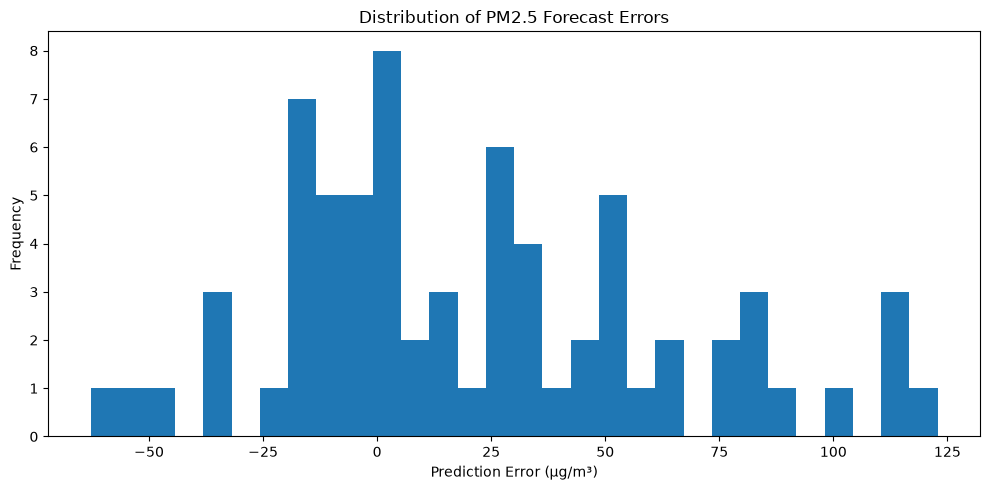

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    comparison_df["error"],
    bins=30
)

plt.title("Distribution of PM2.5 Forecast Errors")
plt.xlabel("Prediction Error (µg/m³)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

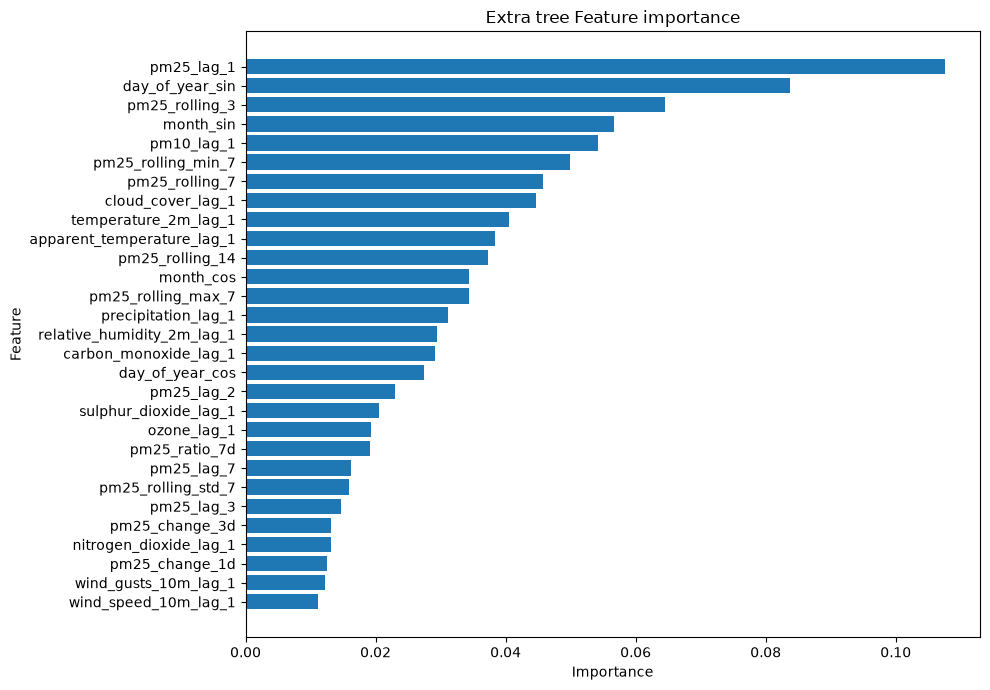

In [42]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": extra_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

feature_importance

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Extra tree Feature importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [43]:
predictions_path = Path(
    "../data/processed/"
    "pm25_forecast_test_predictions.csv"
)

comparison_df.to_csv(
    predictions_path,
    index=False
)

print(
    f"Predictions saved to: {predictions_path}"
)

Predictions saved to: ..\data\processed\pm25_forecast_test_predictions.csv


## Forecasting Results and Conclusion

The forecasting experiment evaluated a persistence baseline and three machine-learning regression models: Linear Regression, Random Forest, Gradient Boosting, and Extra Trees.

The Extra Trees Regressor achieved the best overall performance, with an MAE of 33.86 µg/m³, an RMSE of 44.28 µg/m³, and an R² score of 0.0279.

Compared with the persistence baseline, which achieved an RMSE of 49.41 µg/m³, the Extra Trees model reduced the forecasting error by approximately 10.4%.

Although the positive R² indicates that the model explains some variation in next-day PM2.5 levels, the relatively low R² also shows that next-day pollution remains difficult to predict using the available one-year dataset. This is expected because PM2.5 concentrations can be influenced by complex atmospheric processes, regional transport, emissions, and other factors not captured in the dataset.

The forecasting results therefore demonstrate that machine learning can improve upon a simple persistence-based prediction, while also highlighting the limitations of forecasting from a relatively small single-year dataset.

### Best Model

**Extra Trees Regressor**

- MAE: **33.86 µg/m³**
- RMSE: **44.28 µg/m³**
- R²: **0.0279**

### Important Limitation

The forecasting model is intended for analytical and educational purposes within this project. It should not be interpreted as an official air-quality forecasting system or used for health-related decisions.